# 📦 Supply Chain Optimization Model — Plant & Port Assignment

## 📘 Problem Overview

In modern supply chain networks, the cost of fulfilling customer orders is influenced by both **production costs at manufacturing plants** and **transportation costs from shipping ports**. Companies often manage complex networks with multiple manufacturing plants, connected to various shipping ports, with overlapping product capabilities and special customer constraints such as **Vendor Managed Inventory (VMI)**.

The **goal** of this model is to **assign each customer order to the most cost-effective combination of a plant and a port**, based on:

- Which plants can manufacture the product
- Which ports each plant can ship through
- Which plants are required for certain customers under VMI rules
- The manufacturing costs at each plant
- The average freight rates at each port

---

## ✅ Objective

**Minimize total cost per order** by choosing:
1. A plant to produce the ordered product
2. A connected port to ship the product to the customer

**Total cost = Plant production cost + Port freight cost**

---

## 🧩 Problem Constraints

The optimization is subject to the following **business rules**:

- A product can only be manufactured by specific plants (product-plant mapping)
- A plant can only ship through specific ports (plant-port network)
- Some customers are under VMI and can **only** be served by designated plants
- Freight cost is averaged per port
- Orders for which no valid plant-port pair exists should be excluded from optimization

---

## 📊 Data Used

The model uses the following datasets (from Excel):

- `OrderList`: Customer orders (ID, customer name, product ID, etc.)
- `ProductsPerPlant`: Maps which plants can produce which products
- `PlantPorts`: Maps which ports are accessible to each plant
- `VmiCustomers`: Maps VMI customers to required plants
- `FreightRates`: Raw shipping rates used to calculate average freight per port
- `WhCosts`: Manufacturing cost per plant

---

## 🛠️ Code Functionality Breakdown

The code performs the following steps:

1. **Data Import & Cleaning**:
   - Load Excel sheets into Pandas DataFrames
   - Process mappings from products to plants, plants to ports, customers to VMI plants
   - Calculate average freight cost per port

2. **Valid Assignment Generation**:
   - For each order, identify eligible plants based on product and VMI rules
   - For each valid plant, identify connected ports
   - Calculate total cost (manufacturing + freight) for each valid plant-port pair

3. **Optimization**:
   - Choose the **minimum-cost plant-port combination** for each order
   - Exclude infeasible orders (no valid combination)

4. **Visualization**:
   - 🌐 **Network Graph**: Shows connections between plants and ports
   - 📊 **Bar Charts**:
     - Manufacturing cost per plant
     - Number of products each plant can manufacture
   - 💰 **Cost Distribution**:
     - Box plot with individual order costs annotated in $USD

5. **Export**:
   - Final optimized assignments (Order ID, selected plant, selected port, total cost) are available in a DataFrame
   - Optional: Export to CSV

---

## 🧠 Business Value

This model provides a **scalable foundation** for supply chain and logistics optimization by helping businesses:
- Minimize fulfillment costs
- Respect operational constraints (VMI, plant capabilities, logistics limits)
- Improve visibility into cost drivers across their network

It can be extended to include:
- Dynamic capacities and demand
- Carrier selection
- Route-level optimizations
- Time-based constraints


In [2]:
pip install pandas matplotlib pulp openpyxl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 66.8 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



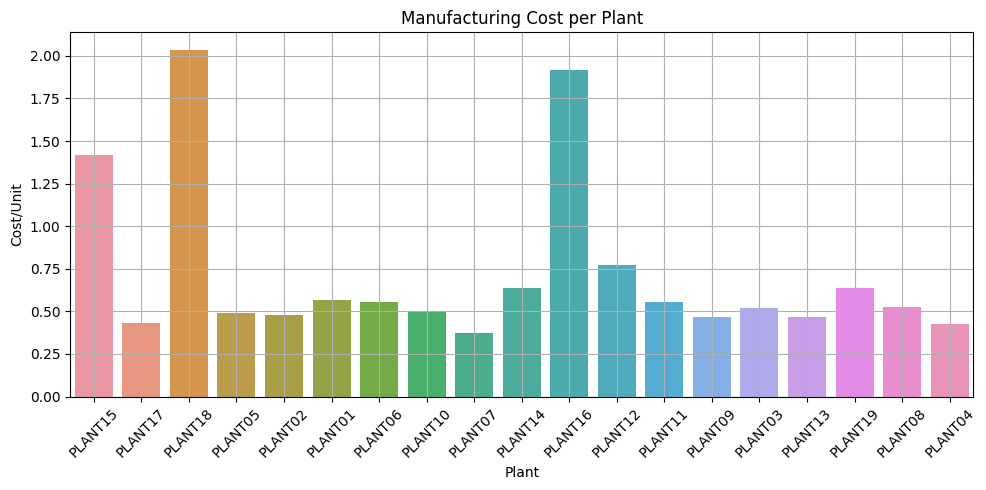

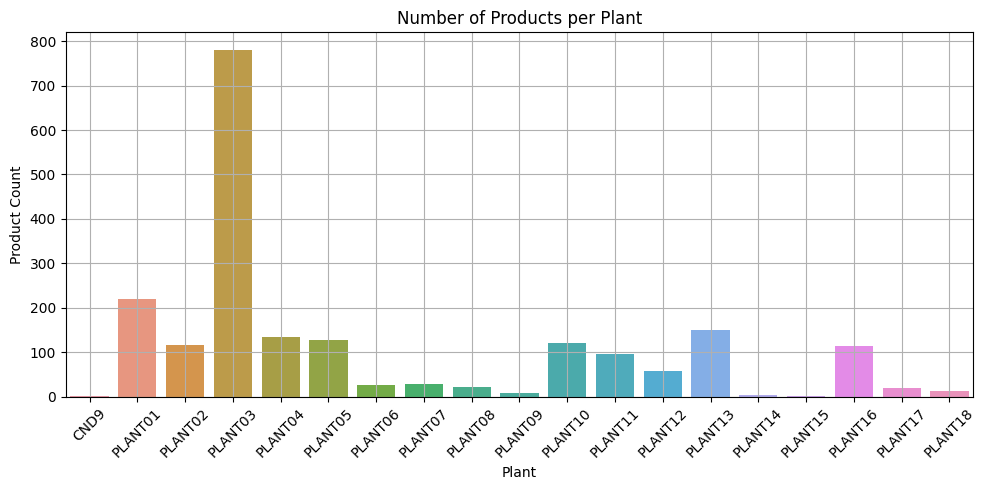

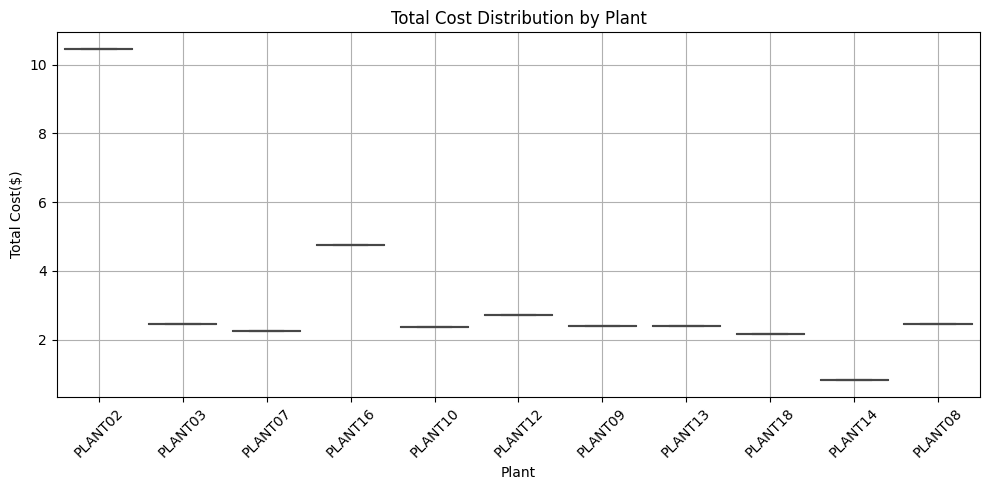

,Order ID,Customer,Product ID,Plant Code,Port,Total Cost
0,1.447126e+09,V55555555_5,1660583,PLANT02,PORT03,10.456881
1,1.447132e+09,V55555555555_28,1667927,PLANT03,PORT04,2.458215
2,1.447133e+09,V555555_24,1678648,PLANT03,PORT04,2.458215
3,1.447133e+09,V55555_26,1668492,PLANT03,PORT04,2.458215
4,1.447133e+09,V55555_26,1683560,PLANT03,PORT04,2.458215


In [16]:
# Supply Chain Optimization: Assign orders to most cost-effective Plant + Port combination

# === 1. IMPORTS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import plotly.graph_objects as go

# === 2. LOAD DATA ===
file_path = '/kaggle/input/supply-chain-data/Supply chain logisitcs problem.xlsx'  # Adjust if needed
xls = pd.ExcelFile(file_path)

order_list = pd.read_excel(xls, 'OrderList')
freight_rates = pd.read_excel(xls, 'FreightRates')
wh_costs = pd.read_excel(xls, 'WhCosts')
products_per_plant = pd.read_excel(xls, 'ProductsPerPlant')
vmi_customers = pd.read_excel(xls, 'VmiCustomers')
plant_ports = pd.read_excel(xls, 'PlantPorts')

# === 3. PREPROCESSING ===
# Product → [Plants]
product_to_plants = products_per_plant.groupby("Product ID")["Plant Code"].apply(list).to_dict()

# Plant → [Ports]
plant_to_ports = plant_ports.groupby("Plant Code")["Port"].apply(list).to_dict()

# VMI Customer → Specific Plant
vmi_customer_plant = dict(zip(vmi_customers["Customers"], vmi_customers["Plant Code"]))

# Avg Freight Rate per Port
avg_freight_rate = freight_rates.groupby("orig_port_cd")["rate"].mean().to_dict()

# Manufacturing Cost per Plant
plant_cost = dict(zip(wh_costs["WH"], wh_costs["Cost/unit"]))

# === 4. BUILD VALID PLANT-PORT OPTIONS ===
valid_assignments = []

for _, row in order_list.iterrows():
    order_id = row["Order ID"]
    customer = row["Customer"]
    product_id = row["Product ID"]
    
    if customer in vmi_customer_plant:
        valid_plants = [vmi_customer_plant[customer]]
    else:
        valid_plants = product_to_plants.get(product_id, [])

    for plant in valid_plants:
        for port in plant_to_ports.get(plant, []):
            if port in avg_freight_rate and plant in plant_cost:
                total_cost = plant_cost[plant] + avg_freight_rate[port]
                valid_assignments.append({
                    "Order ID": order_id,
                    "Customer": customer,
                    "Product ID": product_id,
                    "Plant Code": plant,
                    "Port": port,
                    "Total Cost": total_cost
                })

assignments_df = pd.DataFrame(valid_assignments)

# === 5. SELECT OPTIMAL COMBINATION PER ORDER ===
optimal_assignments = assignments_df.loc[assignments_df.groupby("Order ID")["Total Cost"].idxmin()].reset_index(drop=True)

# === 6. VISUALIZATION ===

## --- (A) NETWORK GRAPH: Plant ↔ Port ---
G = nx.Graph()
for plant, ports in plant_to_ports.items():
    G.add_node(plant, type='plant')
    for port in ports:
        G.add_node(port, type='port')
        G.add_edge(plant, port)

pos = nx.spring_layout(G, seed=42)
edge_x, edge_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(x=edge_x, y=edge_y, line=dict(width=1, color='#888'), mode='lines')
node_x, node_y, node_text, node_color = [], [], [], []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(node)
    node_color.append('blue' if G.nodes[node]['type'] == 'plant' else 'green')

node_trace = go.Scatter(
    x=node_x, y=node_y, mode='markers+text', text=node_text, textposition='top center',
    marker=dict(color=node_color, size=10, line_width=2)
)

network_fig = go.Figure(data=[edge_trace, node_trace])
network_fig.update_layout(title='Plant ↔ Port Network', showlegend=False)
network_fig.show()

## --- (B) Bar Plot: Plant Manufacturing Costs ---
plt.figure(figsize=(10, 5))
sns.barplot(x=list(plant_cost.keys()), y=list(plant_cost.values()))
plt.title("Manufacturing Cost per Plant")
plt.xlabel("Plant")
plt.ylabel("Cost/Unit")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## --- (C) Bar Plot: Number of Products per Plant ---
product_counts = products_per_plant.groupby("Plant Code").size()
plt.figure(figsize=(10, 5))
sns.barplot(x=product_counts.index, y=product_counts.values)
plt.title("Number of Products per Plant")
plt.xlabel("Plant")
plt.ylabel("Product Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## --- (D) Box Plot: Cost Distribution per Plant ---
plt.figure(figsize=(10, 5))
sns.boxplot(x="Plant Code", y="Total Cost", data=optimal_assignments)
plt.title("Total Cost Distribution by Plant")
plt.xlabel("Plant")
plt.ylabel("Total Cost($)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# === 7. EXPORT RESULT (Optional) ===
# optimal_assignments.to_csv("optimized_assignments.csv", index=False)

# === 8. OUTPUT SAMPLE ===
optimal_assignments.head()
